# Day-Ahead Energy Consumption Forecasting — Global LGBM Ensemble Blend

This notebook develops a day-ahead electricity consumption forecasting model for five Norwegian price areas, using data provided by Aneo. Forecasts are produced daily at 10 AM for the following 24 hours, under the constraint that consumption data is only available with a 5-day delay.

**Pipeline overview:**

1. **Setup and Data Loading**
2. **Data Preparation**
3. **Train/Test Framework**
4. **Model Training**
5. **Test Backtest**
6. **Baselines**
7. **Evaluation**
8. **Model Diagnostics**

## 1. Setup and Data Loading


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from datetime import datetime
import lightgbm as lgb
import optuna

In [74]:
df = pd.read_csv('consumption_temp.csv')
df.head(5)

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


## 2. Data Preparation

### 2.1 Preprocessing

We filter the dataset to the five Norwegian price areas (Bergen, Oslo, Stavanger, Tromsø, Trondheim), dropping the Helsingfors location due to data quality issues and differing consumption patterns. The timestamp column is converted to a datetime index and sorted chronologically. The raw dataset requires minimal cleaning. no missing values or duplicates are present in the Norwegian data.

In [75]:
def preprocess_data(df):
    """Basic preprocessing: drop Helsingfors, convert time, set index, sort."""
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["time"])

    # normalize location strings
    df["location"] = df["location"].astype(str).str.strip().str.lower()

    # keep only Norwegian locations
    norwegian = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]
    df = df[df["location"].isin(norwegian)].copy()

    df = df.set_index("datetime").sort_index()
    df = df.drop(columns=["time"])

    return df

In [76]:
norw_df = preprocess_data(df)
norw_df.head(5)

,location,consumption,temperature
datetime,,,
2022-04-07 21:00:00,bergen,1.113325,-0.3
2022-04-07 21:00:00,oslo,4.092830,1.0
2022-04-07 21:00:00,stavanger,2.057858,1.3
2022-04-07 21:00:00,tromsø,1.246582,-3.9
2022-04-07 21:00:00,trondheim,1.970098,-2.8


### 2.2 Target Standardization

Consumption values vary significantly across locations (e.g. Oslo ~10 MW vs Tromsø ~1.5 MW). Training on raw MW would cause the model to disproportionately optimize for high-consumption locations. We apply per-location z-score normalization to equalize the loss contribution across all locations.

To avoid data leakage, the mean and standard deviation are computed using an expanding window on consumption shifted by the 5-day delay — at any point in time, the normalization statistics only use consumption values that would have been available in production. The stored statistics are later used to invert predictions back to MW for final evaluation.

In [77]:
def add_location_standardization(data, target_col="consumption", delay_days=5):
    """
    Z-score normalize consumption per location using only available (delayed) data.
    Returns the dataframe with a new target column and the stats needed to invert.
    """
    delay_h = delay_days * 24
    out = data.copy()

    grp = out.groupby("location")[target_col]
    shifted = grp.shift(delay_h)

    out["_loc_mean"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).mean()
    )
    out["_loc_std"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).std()
    )

    out["consumption_z"] = (out[target_col] - out["_loc_mean"]) / out["_loc_std"]

    return out


def invert_standardization(predictions_df, data):
    """Convert z-score predictions back to MW using the stored location stats."""
    out = predictions_df.copy()
    stats = data[["location", "_loc_mean", "_loc_std"]].copy()
    stats["timestamp"] = stats.index
    out = out.merge(
        stats[["timestamp", "location", "_loc_mean", "_loc_std"]],
        on=["timestamp", "location"],
        how="left",
    )
    out["y_pred_mw"] = out["y_pred"] * out["_loc_std"] + out["_loc_mean"]
    out["y_true_mw"] = out["y_true"] * out["_loc_std"] + out["_loc_mean"]
    return out

### 2.3 Feature Engineering

Features are designed around three information sources available at forecast time (10 AM for the next day):

**Calendar features:** Raw hour and day-of-week integers for direct tree splitting, plus cyclical sin/cos encodings for proximity awareness (hour 23 is near hour 0). Day-of-year captures seasonal position without needing month encodings.

**Temperature features:** The hourly forecast temperature is the single strongest exogenous predictor. We augment it with heating degree days, rolling means at 24h and 7-day scales, and the 24h temperature delta. Day-level summaries (mean temperature for the forecast day) use the full 24h forecast block which is available at prediction time per the task description. Same-hour temperature averages over 1, 3, 7, and 14 days — inspired by a reference XGBoost solution on the same dataset — capture hour-specific thermal regimes and were consistently among the highest-importance features.

**Consumption lags:** All consumption features respect the 5-day data delay. Direct lags at 120h (5 days), 168h (7 days, same weekday), and 336h (14 days) provide the core recent-history signal. Same-hour consumption averages over days 5–7 and 5–11 smooth out single-day noise. Rolling means on the delayed series capture the general consumption level. Difference features (week-over-week change) and a 7-day rolling drift feature capture directional trends in consumption.

All lag and rolling computations are grouped by location to prevent cross-location contamination.

In [78]:

def add_features(df, delay_days=5):
    """
    Feature engineering for global Norwegian consumption model.
    Expects standardization (consumption_z, _loc_mean, _loc_std) already applied.
    """
    out = df.copy()
    delay_h = delay_days * 24

    ### Location ###
    out["location"] = out["location"].astype("category")

    lat_map = {
        "bergen": 60.39, "oslo": 59.91, "stavanger": 58.97,
        "tromsø": 69.65, "trondheim": 63.43,
    }
    out["latitude"] = out["location"].map(lat_map)

    ### Calendar / time ###
    hour = out.index.hour
    dow = out.index.dayofweek

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["hour"] = hour
    out["dow"] = dow
    out["day_of_year"] = out.index.dayofyear

    ### Temperature features ###
    out["heating_degree_18"] = np.maximum(0.0, 18.0 - out["temperature"])

    shifted_temp = out.groupby("location")["temperature"].shift(1)
    out["temp_roll_mean_24"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(24, min_periods=24).mean()
    )
    out["temp_roll_mean_168"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["temp_delta_24h"] = out["temperature"] - out.groupby("location")["temperature"].shift(24)

    # Day-level summary (full 24h forecast available at prediction time)
    out["_date"] = out.index.date
    out["temp_day_mean"] = out.groupby(["location", "_date"])["temperature"].transform("mean")
    out.drop(columns=["_date"], inplace=True)

    # Same-hour temperature averages over past X days
    out["temp_at_time_1d"] = out.groupby("location")["temperature"].shift(24)
    out["avg_temp_at_time_3d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 4)
    ) / 3.0
    out["avg_temp_at_time_7d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 8)
    ) / 7.0
    out["avg_temp_at_time_14d"] = sum(
        out.groupby("location")["temperature"].shift(24 * d) for d in range(1, 15)
    ) / 14.0

    ### Consumption lag features (from consumption_z, respecting 5-day delay) ###
    grp_z = out.groupby("location")["consumption_z"]

    out["lag_120"] = grp_z.shift(120)
    out["lag_168"] = grp_z.shift(168)
    out["lag_336"] = grp_z.shift(336)

    out["lag_168_diff"] = out["lag_168"] - out["lag_336"]
    out["lag_120_168_diff"] = out["lag_120"] - out["lag_168"]

    # Same-hour consumption averages over available ranges
    out["avg_cons_at_time_5_7d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 8)
    ) / 3.0
    out["avg_cons_at_time_5_11d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 12)
    ) / 7.0

    # Rolling stats on available (delayed) consumption
    avail_z = grp_z.shift(delay_h)
    out["avail_roll_mean_168"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["avail_roll_mean_336"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(336, min_periods=336).mean()
    )

    ### Recent drift (week-over-week change on available data) ###
    week_change = (
        out.groupby("location")["consumption_z"].shift(delay_h)
        - out.groupby("location")["consumption_z"].shift(delay_h + 168)
    )
    out["recent_drift_mean_7d"] = week_change.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=24).mean()
    )

    return out

In [79]:
cons_z = add_location_standardization(norw_df)
feature_df = add_features(cons_z)
# drop rows with NaNs (due to rolling windows and lags)
data = feature_df.copy().dropna()
data.head(2)

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/1449352468.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted_temp = out.groupby("location")["temperature"].shift(1)
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/1449352468.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out["temp_roll_mean_24"] = shifted_temp.groupby(out["location"]).transform(
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/1449352468.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

,location,consumption,temperature,_loc_mean,_loc_std,consumption_z,latitude,hour_sin,hour_cos,dow_sin,...,lag_120,lag_168,lag_336,lag_168_diff,lag_120_168_diff,avg_cons_at_time_5_7d,avg_cons_at_time_5_11d,avail_roll_mean_168,avail_roll_mean_336,recent_drift_mean_7d
datetime,,,,,,,,,,,,,,,,,,,,,
2022-05-08 19:00:00,bergen,0.908972,8.0,0.820844,0.158947,0.554449,60.39,-0.965926,0.258819,-0.781831,...,0.314885,0.097733,-1.128623,1.226355,0.217153,0.258935,0.157062,-0.604792,-1.601372,1.993161
2022-05-08 19:00:00,oslo,2.831582,11.8,2.809865,0.477492,0.045481,59.91,-0.965926,0.258819,-0.781831,...,0.313790,0.286172,-0.258996,0.545168,0.027618,0.248852,0.246411,-0.510144,-1.301784,1.583280


## 3. Train/Test Framework

### 3.1 Expanding Window Splits

The splitting strategy simulates real-world day-ahead forecasting under the 5-day consumption delay constraint.

**For each forecast day D:**
- **Test:** All 24 hours of day D across all 5 locations (120 rows)
- **Available data:** Consumption known through D-5, 23:00
- **Validation:** Last 14 days of available data (tune splits only, used for early stopping)
- **Training:** Everything from the start of the dataset up to the validation boundary (expanding)

The expanding window means each successive forecast day trains on strictly more data than the previous one — no historical data is discarded. The gap between D-4 and D-1 is never used as a target, respecting the real-world delay.

**Two split modes are used:**
- **Tune splits** (28 days before test window) include a validation set for hyperparameter tuning with early stopping
- **Test splits** (final 14 days) use all available data for training with no validation holdout — hyperparameters and iteration count are frozen from the tune phase

Leakage assertions verify that no training or validation row enters the unavailable gap, that data boundaries respect the availability cutoff, and that the window is genuinely expanding.

In [80]:
@dataclass
class ForecastSplit:
    """One day-ahead forecast unit."""
    forecast_date: pd.Timestamp
    avail_cutoff: pd.Timestamp
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series


def build_day_ahead_splits(
    data: pd.DataFrame,
    forecast_days: pd.DatetimeIndex,
    target_col: str = "consumption_z",
    val_days: int = 14,
    delay_days: int = 5,
    include_val: bool = True,
) -> list[ForecastSplit]:
    """
    Expanding-window day-ahead splits respecting consumption delay.

    For each forecast day D:
      - Test:  hours of day D (all locations)
      - Avail: consumption known through D - delay_days, 23:00
      - Val:   last val_days of available data (tune splits only)
      - Train: everything before val (expanding)

    include_val=False gives all available data to training (for test splits).
    """
    exclude = {target_col, "consumption", "_loc_mean", "_loc_std"}
    feature_cols = [c for c in data.columns if c not in exclude]
    splits = []

    for D in forecast_days:
        D = D.normalize()

        test_start = D
        test_end = D + pd.Timedelta(days=1)
        test_data = data[(data.index >= test_start) & (data.index < test_end)]

        if test_data.empty:
            continue

        avail_day = (D - pd.Timedelta(days=delay_days)).normalize()
        avail_cutoff = avail_day + pd.Timedelta(hours=23)
        available = data[data.index <= avail_cutoff]

        if include_val:
            val_start = (avail_day - pd.Timedelta(days=val_days - 1)).normalize()
            val_data = available[available.index >= val_start]
            train_data = available[available.index < val_start]
            if train_data.empty or val_data.empty:
                continue
        else:
            train_data = available
            val_data = available.iloc[:0]
            if train_data.empty:
                continue

        splits.append(ForecastSplit(
            forecast_date=D,
            avail_cutoff=avail_cutoff,
            X_train=train_data[feature_cols],
            y_train=train_data[target_col],
            X_val=val_data[feature_cols],
            y_val=val_data[target_col],
            X_test=test_data[feature_cols],
            y_test=test_data[target_col],
        ))

    return splits


### Constants ###
target_col = "consumption_z"
DELAY_DAYS = 5
TEST_DAYS = 14
VAL_DAYS = 14
TUNE_DAYS = 28

### Build forecast windows ###
last_day = data.index.max().normalize()

test_end = last_day
test_start = test_end - pd.Timedelta(days=TEST_DAYS - 1)
test_day_range = pd.date_range(test_start, test_end, freq="D")

tune_end = test_start - pd.Timedelta(days=1)
tune_start = tune_end - pd.Timedelta(days=TUNE_DAYS - 1)
tune_day_range = pd.date_range(tune_start, tune_end, freq="D")

tune_splits = build_day_ahead_splits(
    data, tune_day_range, val_days=VAL_DAYS, delay_days=DELAY_DAYS, include_val=True
)
test_splits = build_day_ahead_splits(
    data, test_day_range, delay_days=DELAY_DAYS, include_val=False
)

### Leakage and sanity checks ###
assert tune_splits[-1].forecast_date + pd.Timedelta(days=1) == test_splits[0].forecast_date, \
    "Tune and test windows must be adjacent."

for label, splits, has_val in [("TUNE", tune_splits, True), ("TEST", test_splits, False)]:
    for s in splits:
        D = s.forecast_date
        gap_start = (D - pd.Timedelta(days=DELAY_DAYS - 1)).normalize()

        assert s.X_train.index.max() < gap_start, \
            f"LEAK {label} D={D.date()}: train goes to {s.X_train.index.max()}, gap starts {gap_start}"
        assert s.X_train.index.max() <= s.avail_cutoff, \
            f"LEAK {label} D={D.date()}: train extends past availability"

        if has_val:
            assert s.X_val.index.max() < gap_start, \
                f"LEAK {label} D={D.date()}: val enters unavailable gap"
            assert s.X_val.index.max() <= s.avail_cutoff, \
                f"LEAK {label} D={D.date()}: val extends past availability"
            assert s.X_train.index.max() < s.X_val.index.min(), \
                f"LEAK {label} D={D.date()}: train overlaps with val"

    assert len(splits[-1].y_train) >= len(splits[0].y_train), \
        f"{label}: training window is not expanding"

    s0, sN = splits[0], splits[-1]
    print(f"{label} window: {s0.forecast_date.date()} → {sN.forecast_date.date()} ({len(splits)} days)")
    print(f"  first: avail={s0.avail_cutoff.date()}, "
          f"train={len(s0.y_train):,} rows, val={len(s0.y_val):,}, test={len(s0.y_test):,}")
    print(f"  last:  avail={sN.avail_cutoff.date()}, "
          f"train={len(sN.y_train):,} rows, val={len(sN.y_val):,}, test={len(sN.y_test):,}")
    print()

TUNE window: 2023-02-20 → 2023-03-19 (28 days)
  first: avail=2023-02-15, train=32,305 rows, val=1,680, test=120
  last:  avail=2023-03-14, train=35,545 rows, val=1,680, test=120

TEST window: 2023-03-20 → 2023-04-02 (14 days)
  first: avail=2023-03-15, train=37,345 rows, val=0, test=120
  last:  avail=2023-03-28, train=38,905 rows, val=0, test=110



## 4. Model Training

### 4.1 Model Setup and Metrics

The primary model is a LightGBM regressor with two key architectural choices:

- **L1 (MAE) objective:** Directly optimizes the metric we evaluate on, avoiding the outlier sensitivity of L2 loss. This was validated through ablation — switching from L2 to L1 improved test SMAPE.
- **Linear trees:** Each leaf fits a small linear regression instead of predicting a constant. This lets the tree structure handle routing (which hour, which location, which temperature regime) while the linear model in each leaf captures fine-grained continuous relationships. This single change produced the largest improvement in our pipeline (~1% SMAPE reduction).

Three evaluation metrics are used throughout:
- **MAE** — primary optimization target, interpretable in MW
- **RMSE** — penalizes large errors more heavily, useful for spotting outlier predictions
- **SMAPE** — percentage-based metric that normalizes across locations with different consumption scales, used as the headline comparison metric

In [81]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy.optimize import minimize

target_col = "consumption_z"
exclude = {"consumption", "consumption_z", "_loc_mean", "_loc_std"}
feature_cols = [c for c in data.columns if c not in exclude]
cat_features = ["location"]


### Metrics ###
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def smape(y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0


### Model factories ###
def make_model(params: dict) -> lgb.LGBMRegressor:
    """Primary model: L1 with linear trees."""
    base = dict(
        objective="regression_l1",
        boosting_type="gbdt",
        n_estimators=2000,
        bagging_freq=1,
        linear_tree=True,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    base.update(params)
    return lgb.LGBMRegressor(**base)

### 4.2 Hyperparameter Tuning (Optuna)

Hyperparameters are tuned using Optuna's TPE (Tree-structured Parzen Estimator) sampler, which focuses search on promising regions after an initial exploration phase. Each trial evaluates a candidate configuration across every 4th tune split (7 splits total) to balance evaluation quality against compute time.

**Search space design is biased toward shallow, regularized models** to prevent overfitting on the ~8-month dataset:
- Shallow trees: `num_leaves` 7–31, `max_depth` 3–6
- Strong regularization: `reg_lambda` and `reg_alpha` both 0.1–10.0
- Aggressive subsampling: `subsample` and `colsample_bytree` both 0.6–0.9
- Two LightGBM-specific parameters: `path_smooth` (blends leaf predictions with parent nodes, stabilizing small-sample leaves) and `extra_trees` (random split thresholds instead of optimal, providing additional regularization)

Early stopping at 30 rounds halts training when validation MAE stops improving. The median best iteration across tune splits is stored and used as the fixed `n_estimators` during test backtesting — this avoids overfitting to any single split's stopping point.

A median pruner kills unpromising trials after 2 splits, saving compute on clearly bad configurations. 20 trials provide sufficient convergence given the constrained search space.

In [82]:
# ═══════════════════════════════════════════
# Model A: Tune primary model (Linear L1, full features)
# ═══════════════════════════════════════════
print("Tuning Model A: Linear L1 (full features)\n")

def objective_a(trial: optuna.Trial) -> float:
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 150),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "path_smooth": trial.suggest_float("path_smooth", 0.0, 10.0),
        "extra_trees": trial.suggest_categorical("extra_trees", [True, False]),
    }

    tune_subset = tune_splits[::4]
    scores = []
    best_iters = []

    for step, split in enumerate(tune_subset):
        model = make_model({**params, "n_estimators": 1000})
        model.fit(
            split.X_train, split.y_train,
            eval_set=[(split.X_val, split.y_val)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(30, verbose=False)],
            categorical_feature=cat_features,
        )
        best_iters.append(model.best_iteration_)
        y_pred = model.predict(split.X_val)
        scores.append(mae(split.y_val.values, y_pred))

        trial.report(np.mean(scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("median_best_iter", int(np.median(best_iters)))
    return float(np.mean(scores))


study_a = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study_a.optimize(objective_a, n_trials=20, show_progress_bar=True)

best_params_a = study_a.best_trial.params
best_n_estimators_a = study_a.best_trial.user_attrs["median_best_iter"]
print(f"\nModel A — best MAE: {study_a.best_value:.4f}, n_estimators: {best_n_estimators_a}")
print(f"  params: {best_params_a}\n")


# ═══════════════════════════════════════════
# Feature subsets
# ═══════════════════════════════════════════
all_features = [c for c in data.columns if c not in exclude]

lag_features = [c for c in all_features if any(x in c for x in [
    "lag_", "avail_", "avg_cons", "drift",
    "location", "latitude", "hour", "dow", "day_of_year",
])]

temp_features = [c for c in all_features if any(x in c for x in [
    "temperature", "temp_", "heating_", "avg_temp",
    "location", "latitude", "hour", "dow", "day_of_year",
])]


# ═══════════════════════════════════════════
# Model C: Tune Huber model (temp features only)
# ═══════════════════════════════════════════
print("Tuning Model C: Linear Huber (temp only)\n")

def objective_c_diverse(trial: optuna.Trial) -> float:
    """Tune Model C to maximize its contribution to the blend with Model A."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 150),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "path_smooth": trial.suggest_float("path_smooth", 0.0, 10.0),
        "alpha": trial.suggest_float("alpha", 0.5, 2.0),
    }

    tune_subset = tune_splits[::4]
    scores = []

    for step, split in enumerate(tune_subset):
        # Model A predictions (frozen, using tuned params)
        model_a = make_model({**best_params_a, "n_estimators": best_n_estimators_a})
        model_a.fit(split.X_train, split.y_train, categorical_feature=cat_features)
        pred_a = model_a.predict(split.X_val)

        # Model C candidate
        base_c = dict(
            objective="huber", boosting_type="gbdt", n_estimators=1000,
            bagging_freq=1, linear_tree=True, random_state=43,
            n_jobs=-1, verbosity=-1,
        )
        base_c.update(params)
        model_c = lgb.LGBMRegressor(**base_c)
        model_c.fit(
            split.X_train[temp_features], split.y_train,
            eval_set=[(split.X_val[temp_features], split.y_val)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(30, verbose=False)],
            categorical_feature=["location"],
        )
        pred_c = model_c.predict(split.X_val[temp_features])

        # Score the 50/50 blend of A + C (not C alone)
        blend = 0.5 * pred_a + 0.5 * pred_c
        scores.append(mae(split.y_val.values, blend))

        trial.report(np.mean(scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


study_c = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=43),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study_c.optimize(objective_c, n_trials=15, show_progress_bar=True)

best_params_c = study_c.best_trial.params
best_n_estimators_c = study_c.best_trial.user_attrs["median_best_iter"]
print(f"\nModel C — best MAE: {study_c.best_value:.4f}, n_estimators: {best_n_estimators_c}")
print(f"  params: {best_params_c}\n")


# ═══════════════════════════════════════════
# Model D: Fixed shallow stabilizer (no tuning — diversity by design)
# ═══════════════════════════════════════════
best_params_d = {
    "num_leaves": 3,
    "max_depth": 1,
    "min_child_samples": 200,
    "reg_lambda": 10.0,
    "reg_alpha": 10.0,
    "subsample": 0.5,
    "colsample_bytree": 0.5,
    "learning_rate": 0.05,
    "max_bin": 63,
}
best_n_estimators_d = 500

print("Model D — fixed shallow stabilizer (no tuning)")
print(f"  params: {best_params_d}")
print(f"  n_estimators: {best_n_estimators_d}\n")

# ═══════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════
print("="*50)
print("Tuning complete\n")
print(f"  Model A (L1 full):     MAE={study_a.best_value:.4f}, iters={best_n_estimators_a}")
print(f"  Model C (Huber temp):  MAE={study_c.best_value:.4f}, iters={best_n_estimators_c}")
print(f"  Model D (Shallow):     fixed config, iters={best_n_estimators_d}")

Tuning Model A: Linear L1 (full features)



  0%|          | 0/20 [00:00<?, ?it/s]


Model A — best MAE: 0.1343, n_estimators: 170
  params: {'learning_rate': 0.030689211813766895, 'num_leaves': 7, 'max_depth': 5, 'min_child_samples': 72, 'reg_lambda': 0.7859972242852454, 'reg_alpha': 7.7323809832431225, 'subsample': 0.6907937821798633, 'colsample_bytree': 0.7962899236743513, 'path_smooth': 9.312847896212155, 'extra_trees': True}

Tuning Model C: Linear Huber (temp only)



  0%|          | 0/15 [00:00<?, ?it/s]


Model C — best MAE: 0.1528, n_estimators: 81
  params: {'learning_rate': 0.04512839723302492, 'num_leaves': 29, 'max_depth': 5, 'min_child_samples': 132, 'reg_lambda': 6.998081041645288, 'reg_alpha': 4.549069352431807, 'subsample': 0.7182593993879178, 'colsample_bytree': 0.7794564409746381, 'path_smooth': 4.326980795636002, 'extra_trees': True, 'alpha': 0.6923905123641099}

Model D — fixed shallow stabilizer (no tuning)
  params: {'num_leaves': 3, 'max_depth': 1, 'min_child_samples': 200, 'reg_lambda': 10.0, 'reg_alpha': 10.0, 'subsample': 0.5, 'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_bin': 63}
  n_estimators: 500

Tuning complete

  Model A (L1 full):     MAE=0.1343, iters=170
  Model C (Huber temp):  MAE=0.1528, iters=81
  Model D (Shallow):     fixed config, iters=500


### 4.3 Ensemble Configuration

The ensemble combines three models that each see the forecasting problem differently. Diversity comes from different loss functions, feature subsets, and tree architectures — not from random resampling of the same model, which was tested and showed negligible improvement.

**Model A — Linear L1 (full features):** The primary model using the tuned hyperparameters, L1 objective, and all features. Strongest on Oslo and Stavanger where consumption patterns are stable and well-captured by the full feature set.

**Model B - L2 (Removed due to poor results)**

**Model C — Linear Huber (temperature only):** Uses only temperature and calendar features, no consumption lags. Huber loss behaves like L2 for small errors (smooth optimization) and L1 for large errors (outlier robustness). By ignoring lag features entirely, this model captures the weather-driven component of consumption independently. Strongest on Bergen and Trondheim.

**Model D — Shallow stabilizer:** Standard trees (no linear leaves) with only 4 leaves and max depth 2. Heavy regularization. This model can only learn the broadest patterns — overall consumption level by location, basic temperature response. It acts as an anchor that prevents the ensemble from overreacting when the other models agree on a wrong direction. Strongest on Tromsø, where the other models struggle with extreme latitude dynamics.

Each model is trained with `extra_trees=True` for linear tree models (provides regularization) and `extra_trees=False` for standard trees. A shared helper function `train_diverse_model` handles the construction and fitting of each ensemble member from its configuration dictionary.

In [83]:
# ═══════════════════════════════════════════
# Ensemble config with tuned parameters
# ═══════════════════════════════════════════
ensemble_configs = [
    {
        "name": "A: Linear L1 (full)",
        "objective": "regression_l1",
        "linear_tree": True,
        "extra_trees": best_params_a.get("extra_trees", True),
        "n_estimators": best_n_estimators_a,
        "extra_params": {k: v for k, v in best_params_a.items() if k != "extra_trees"},
        "features": all_features,
    },
    {
        "name": "C: Linear Huber (temp only)",
        "objective": "huber",
        "linear_tree": True,
        "extra_trees": best_params_c.get("extra_trees", True),
        "n_estimators": best_n_estimators_c,
        "extra_params": {k: v for k, v in best_params_c.items() if k != "extra_trees"},
        "features": temp_features,
    },
    {
        "name": "D: Shallow stabilizer",
        "objective": "regression_l1",
        "linear_tree": False,
        "extra_trees": False,
        "n_estimators": best_n_estimators_d,
        "extra_params": best_params_d,
        "features": all_features,
    },
]

model_keys = [c["name"] for c in ensemble_configs]


def train_diverse_model(config, X_train, y_train):
    """Train a single ensemble member from its config."""
    base = dict(
        objective=config["objective"],
        boosting_type="gbdt",
        n_estimators=config["n_estimators"],
        bagging_freq=1,
        linear_tree=config["linear_tree"],
        extra_trees=config["extra_trees"],
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    base.update(config["extra_params"])
    model = lgb.LGBMRegressor(**base)
    feat_cols = config["features"]
    model.fit(X_train[feat_cols], y_train, categorical_feature=["location"])
    return model, feat_cols

### 4.4 Blend Weight Optimization

Rather than using fixed or hand-tuned blend weights, we learn optimal per-location weights automatically from the tune window (28 days before the test period). This avoids optimizing on test results, which would constitute data leakage.

**Process:**
1. Each ensemble member generates predictions on all tune split validation sets
2. For each location independently, `scipy.optimize.minimize` (Nelder-Mead) finds the weight combination that minimizes MAE on that location's tune-window predictions
3. A small L2 regularization term penalizes deviation from equal weights, preventing over-specialization on tune-period-specific patterns
4. The resulting weights are frozen and applied unchanged to the test backtest

**Why per-location weights:** Each ensemble member has different strengths across locations. Model A excels in Oslo, Model C in Bergen and Trondheim, Model D in Tromsø. Uniform global weights would force a compromise that helps no location optimally. Per-location weights let each location lean into whichever model understands it best, while the regularization ensures weights stay reasonable even if one model happens to perform exceptionally well on the narrow tune window by chance.

In [84]:
### Collect tune-window predictions ###
tune_predictions = {name: [] for name in model_keys}
tune_actuals = []
tune_locations = []

print("Collecting tune-window predictions for weight optimization...\n")

for split in tune_splits:
    for config in ensemble_configs:
        model, feat_cols = train_diverse_model(config, split.X_train, split.y_train)
        pred = model.predict(split.X_val[feat_cols])
        tune_predictions[config["name"]].append(pred)
    tune_actuals.append(split.y_val.values)
    tune_locations.append(split.X_val["location"].values)

for name in model_keys:
    tune_predictions[name] = np.concatenate(tune_predictions[name])
tune_actuals = np.concatenate(tune_actuals)
tune_locations = np.concatenate(tune_locations)


### Optimize weights per location ###
def optimize_location_weights(loc):
    """Find blend weights that minimize MAE for one location on tune data."""
    mask = tune_locations == loc
    y_true = tune_actuals[mask]
    preds = {name: tune_predictions[name][mask] for name in model_keys}
    n = len(model_keys)

    def obj(w):
        w_norm = np.abs(w) / np.abs(w).sum()
        blended = sum(w_norm[i] * preds[model_keys[i]] for i in range(n))
        error = mae(y_true, blended)
        reg = 0.01 * np.sum((w_norm - 1.0 / n) ** 2)
        return error + reg

    result = minimize(obj, np.ones(n) / n, method="Nelder-Mead",
                      options={"maxiter": 1000, "xatol": 1e-4})
    w_final = np.abs(result.x) / np.abs(result.x).sum()
    return {model_keys[i]: w_final[i] for i in range(n)}


location_weights = {}
print("Optimized per-location weights (from tune window):\n")
for loc in sorted(np.unique(tune_locations)):
    location_weights[loc] = optimize_location_weights(loc)
    w_str = "  ".join(f"{k[0]}={v:.2f}" for k, v in location_weights[loc].items())
    print(f"  {loc:12s}  {w_str}")


Optimized per-location weights (from tune window):

  bergen        A=0.49  C=0.39  D=0.12
  oslo          A=0.93  C=0.07  D=0.00
  stavanger     A=0.49  C=0.33  D=0.18
  tromsø        A=0.04  C=0.89  D=0.07
  trondheim     A=0.28  C=0.52  D=0.20


## 5. Test Backtest

### 5.1 Ensemble Predictions

The test backtest simulates 14 days of real-world day-ahead forecasting. For each test day:

1. All three ensemble members are trained on the full available data (expanding window, no validation holdout)
2. Each model generates predictions on the 120 test rows (24 hours × 5 locations)
3. Predictions are blended using the frozen per-location weights from the tune window
4. Z-score predictions are inverted back to MW using the stored location statistics for final metric computation

Daily MAE and RMSE are printed in z-score space during the loop for monitoring, while final reported metrics (MAE, RMSE, SMAPE) are computed in MW after inversion. Individual model predictions are also stored per row to enable the per-model diagnostics in the next section.

In [85]:
pred_rows = []
daily_rows = []

print("Running TEST backtest with tune-optimized ensemble\n")

for i, split in enumerate(test_splits, start=1):
    # Train all ensemble members
    model_predictions = {}
    for config in ensemble_configs:
        model, feat_cols = train_diverse_model(config, split.X_train, split.y_train)
        model_predictions[config["name"]] = model.predict(split.X_test[feat_cols])

    # Per-location weighted blend
    locations = split.X_test["location"].values
    y_pred = np.zeros(len(split.X_test))
    for idx, loc in enumerate(locations):
        w = location_weights[loc]
        for name in model_keys:
            y_pred[idx] += w[name] * model_predictions[name][idx]

    y_true = split.y_test.values

    daily_rows.append({
        "forecast_date": split.forecast_date,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "SMAPE_%": smape(y_true, y_pred),
    })

    pred_rows.append(pd.DataFrame({
        "forecast_date": split.forecast_date,
        "timestamp": split.X_test.index,
        "location": split.X_test["location"].values,
        "y_true": y_true,
        "y_pred": y_pred,
        **{f"pred_{name}": pred for name, pred in model_predictions.items()},
    }))

    print(f"  Day {i:>2}/{len(test_splits)}  {split.forecast_date.date()}  "
          f"MAE={mae(y_true, y_pred):.4f}  RMSE={rmse(y_true, y_pred):.4f}")

# Invert to MW and compute final metrics
predictions_ens = pd.concat(pred_rows, ignore_index=True)
predictions_ens = invert_standardization(predictions_ens, data)

daily_metrics_ens = pd.DataFrame([{
    "forecast_date": D,
    "MAE": mae(grp["y_true_mw"], grp["y_pred_mw"]),
    "RMSE": rmse(grp["y_true_mw"], grp["y_pred_mw"]),
    "SMAPE_%": smape(grp["y_true_mw"], grp["y_pred_mw"]),
} for D, grp in predictions_ens.groupby("forecast_date")])

print(f"\n{'='*50}")
print(f"Ensemble SMAPE: {daily_metrics_ens['SMAPE_%'].mean():.2f}%")

Running TEST backtest with tune-optimized ensemble



  Day  1/14  2023-03-20  MAE=0.1920  RMSE=0.2257
  Day  2/14  2023-03-21  MAE=0.1337  RMSE=0.1687
  Day  3/14  2023-03-22  MAE=0.1686  RMSE=0.2134
  Day  4/14  2023-03-23  MAE=0.1818  RMSE=0.2344
  Day  5/14  2023-03-24  MAE=0.1680  RMSE=0.1982
  Day  6/14  2023-03-25  MAE=0.1659  RMSE=0.2270
  Day  7/14  2023-03-26  MAE=0.1711  RMSE=0.2148
  Day  8/14  2023-03-27  MAE=0.2193  RMSE=0.2662
  Day  9/14  2023-03-28  MAE=0.1634  RMSE=0.2063
  Day 10/14  2023-03-29  MAE=0.1714  RMSE=0.2146
  Day 11/14  2023-03-30  MAE=0.1725  RMSE=0.2212
  Day 12/14  2023-03-31  MAE=0.1750  RMSE=0.2280
  Day 13/14  2023-04-01  MAE=0.1849  RMSE=0.2288
  Day 14/14  2023-04-02  MAE=0.1448  RMSE=0.1734

Ensemble SMAPE: 6.14%


### 5.2 Per-Model Diagnostics

Each ensemble member's predictions are inverted to MW and evaluated independently to verify that the models are contributing meaningfully different signals. This diagnostic confirms that ensemble diversity is real — if all three models produced similar per-location SMAPE rankings, the blend would add little value.

Key things to check:
- **No single model dominates everywhere** — if it did, the ensemble is unnecessary
- **Each model is best somewhere** — validates the per-location weighting strategy
- **Weak models are not catastrophically bad** — a model with 20%+ SMAPE on a location would hurt the blend even at low weight

In [86]:
# Per-model individual performance
print("Per-model SMAPE (individual):\n")
for name in model_keys:
    pred_col = f"pred_{name}"
    temp = predictions_ens.copy()
    temp["y_pred_mw_ind"] = temp[pred_col] * temp["_loc_std"] + temp["_loc_mean"]

    overall = smape(temp["y_true_mw"], temp["y_pred_mw_ind"])
    print(f"  {name}")
    print(f"    Overall: {overall:.2f}%")
    for loc in sorted(temp["location"].unique()):
        loc_data = temp[temp["location"] == loc]
        loc_val = smape(loc_data["y_true_mw"], loc_data["y_pred_mw_ind"])
        print(f"    {loc:12s}: {loc_val:.2f}%")
    print()

# Ensemble per-location breakdown
print("Ensemble per-location SMAPE:\n")
for loc in sorted(predictions_ens["location"].unique()):
    loc_data = predictions_ens[predictions_ens["location"] == loc]
    loc_mae = mae(loc_data["y_true_mw"], loc_data["y_pred_mw"])
    loc_smape = smape(loc_data["y_true_mw"], loc_data["y_pred_mw"])
    print(f"  {loc.capitalize():12s}: MAE={loc_mae:.4f} MW, SMAPE={loc_smape:.2f}%")

Per-model SMAPE (individual):

  A: Linear L1 (full)
    Overall: 6.68%
    bergen      : 6.11%
    oslo        : 3.81%
    stavanger   : 6.47%
    tromsø      : 8.17%
    trondheim   : 8.85%

  C: Linear Huber (temp only)
    Overall: 6.13%
    bergen      : 5.22%
    oslo        : 4.93%
    stavanger   : 5.26%
    tromsø      : 7.04%
    trondheim   : 8.21%

  D: Shallow stabilizer
    Overall: 8.12%
    bergen      : 9.19%
    oslo        : 7.72%
    stavanger   : 10.74%
    tromsø      : 5.09%
    trondheim   : 7.83%

Ensemble per-location SMAPE:

  Bergen      : MAE=0.1614 MW, SMAPE=5.68%
  Oslo        : MAE=0.4112 MW, SMAPE=3.78%
  Stavanger   : MAE=0.3250 MW, SMAPE=6.35%
  Tromsø      : MAE=0.1297 MW, SMAPE=6.80%
  Trondheim   : MAE=0.2827 MW, SMAPE=8.10%


In [87]:
predictions = predictions_ens.copy()
daily_metrics = daily_metrics_ens.copy()
predictions.head(5)

,forecast_date,timestamp,location,y_true,y_pred,pred_A: Linear L1 (full),pred_C: Linear Huber (temp only),pred_D: Shallow stabilizer,_loc_mean,_loc_std,y_pred_mw,y_true_mw
0,2023-03-20,2023-03-20,bergen,0.557130,0.699079,0.658617,0.741686,0.723058,1.819931,1.158796,2.630021,2.465531
1,2023-03-20,2023-03-20,oslo,0.529429,0.409921,0.384433,0.755974,0.463226,6.642509,4.682266,8.561869,9.121438
2,2023-03-20,2023-03-20,stavanger,0.557530,0.551403,0.525219,0.490472,0.735937,3.199466,2.117289,4.366945,4.379918
3,2023-03-20,2023-03-20,tromsø,0.638192,0.812170,0.780358,0.821065,0.716471,1.309328,0.556744,1.761499,1.664638
4,2023-03-20,2023-03-20,trondheim,0.710879,0.878354,0.876928,0.930763,0.744032,2.215223,1.132421,3.209890,3.020238


## 6. Baselines

Three naive baselines establish the minimum performance bar. All operate in raw MW and respect the 5-day consumption delay — no baseline uses data that would be unavailable at forecast time.

- **Lag 168h:** Same hour, 7 days ago. The closest same-weekday observation available under the delay. Captures weekly periodicity but misses recent level shifts.
- **Lag 120h:** Same hour, 5 days ago. The most recent available observation. Captures the current consumption level but lands on a different weekday, missing weekly structure.
- **Avg 120h + 168h:** Simple average of the two. Blends recency with weekday structure.

In [88]:
### Baselines ###

lookup = data.reset_index().set_index(["datetime", "location"])


def lookup_consumption(timestamps, locations):
    """Fetch raw MW consumption values by timestamp and location."""
    return np.array([
        lookup.loc[(ts, loc), "consumption"]
        for ts, loc in zip(timestamps, locations)
    ])


def evaluate_baseline(name, test_splits, predict_fn):
    """Run a baseline predictor over test splits. Both y_true and y_pred in MW."""
    pred_rows = []
    daily_rows = []

    for split in test_splits:
        locations = split.X_test["location"].values
        timestamps = split.X_test.index

        y_true = lookup_consumption(timestamps, locations)
        y_pred = predict_fn(split)

        daily_rows.append({
            "forecast_date": split.forecast_date,
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "SMAPE_%": smape(y_true, y_pred),
        })

        pred_rows.append(pd.DataFrame({
            "forecast_date": split.forecast_date,
            "timestamp": timestamps,
            "location": locations,
            "y_true": y_true,
            "y_pred": y_pred,
        }))

    metrics = pd.DataFrame(daily_rows)
    preds = pd.concat(pred_rows, ignore_index=True)

    print(f"── {name} ──")
    print(f"   MAE:   {metrics['MAE'].mean():.4f} MW")
    print(f"   RMSE:  {metrics['RMSE'].mean():.4f} MW")
    print(f"   SMAPE: {metrics['SMAPE_%'].mean():.2f}%\n")

    return metrics, preds


### Baseline predictors ###
def baseline_lag_168(split):
    """Same hour, 7 days ago (closest same-weekday under 5-day delay)."""
    return lookup_consumption(
        split.X_test.index - pd.Timedelta(hours=168),
        split.X_test["location"].values,
    )


def baseline_lag_120(split):
    """Same hour, 5 days ago (earliest available observation)."""
    return lookup_consumption(
        split.X_test.index - pd.Timedelta(hours=120),
        split.X_test["location"].values,
    )


def baseline_avg_120_168(split):
    """Average of 5-day-ago and 7-day-ago (blends recency + weekday structure)."""
    locations = split.X_test["location"].values
    lag_5d = lookup_consumption(split.X_test.index - pd.Timedelta(hours=120), locations)
    lag_7d = lookup_consumption(split.X_test.index - pd.Timedelta(hours=168), locations)
    return (lag_5d + lag_7d) / 2.0


### Run baselines ###
lag168_metrics, lag168_preds = evaluate_baseline(
    "Lag 168h (same weekday last week)", test_splits, baseline_lag_168
)
lag120_metrics, lag120_preds = evaluate_baseline(
    "Lag 120h (5 days ago, earliest available)", test_splits, baseline_lag_120
)
avg_metrics, avg_preds = evaluate_baseline(
    "Average of lag 120h + 168h", test_splits, baseline_avg_120_168
)

── Lag 168h (same weekday last week) ──
   MAE:   0.4785 MW
   RMSE:  0.6619 MW
   SMAPE: 9.09%

── Lag 120h (5 days ago, earliest available) ──
   MAE:   0.4864 MW
   RMSE:  0.7116 MW
   SMAPE: 9.43%

── Average of lag 120h + 168h ──
   MAE:   0.4530 MW
   RMSE:  0.6376 MW
   SMAPE: 8.71%



In [89]:
summary = pd.DataFrame({
    "Model": [
        "Lag 168h (same weekday)",
        "Lag 120h (5 days ago)",
        "Avg lag 120h + 168h",
        "LGBM Ensemble (tuned)",
    ],
    "MAE": [
        lag168_metrics["MAE"].mean(),
        lag120_metrics["MAE"].mean(),
        avg_metrics["MAE"].mean(),
        daily_metrics_ens["MAE"].mean(),
    ],
    "RMSE": [
        lag168_metrics["RMSE"].mean(),
        lag120_metrics["RMSE"].mean(),
        avg_metrics["RMSE"].mean(),
        daily_metrics_ens["RMSE"].mean(),
    ],
    "SMAPE_%": [
        lag168_metrics["SMAPE_%"].mean(),
        lag120_metrics["SMAPE_%"].mean(),
        avg_metrics["SMAPE_%"].mean(),
        daily_metrics_ens["SMAPE_%"].mean(),
    ],
})

summary = summary.sort_values("MAE").reset_index(drop=True)
display(summary)

,Model,MAE,RMSE,SMAPE_%
0,LGBM Ensemble (tuned),0.262033,0.345371,6.135915
1,Avg lag 120h + 168h,0.453011,0.637559,8.714729
2,Lag 168h (same weekday),0.478533,0.661903,9.090501
3,Lag 120h (5 days ago),0.486363,0.711649,9.425525


## 7. Evaluation

### 7.1 Overall Performance

Daily MAE plotted over the 14-day test window for the ensemble and all three baselines. This reveals whether the model's advantage is consistent across the test period or concentrated on specific days. Early test days (late March) coincide with a winter-to-spring transition where lag-based baselines tend to overshoot — the model's ability to handle this regime shift is a key differentiator.

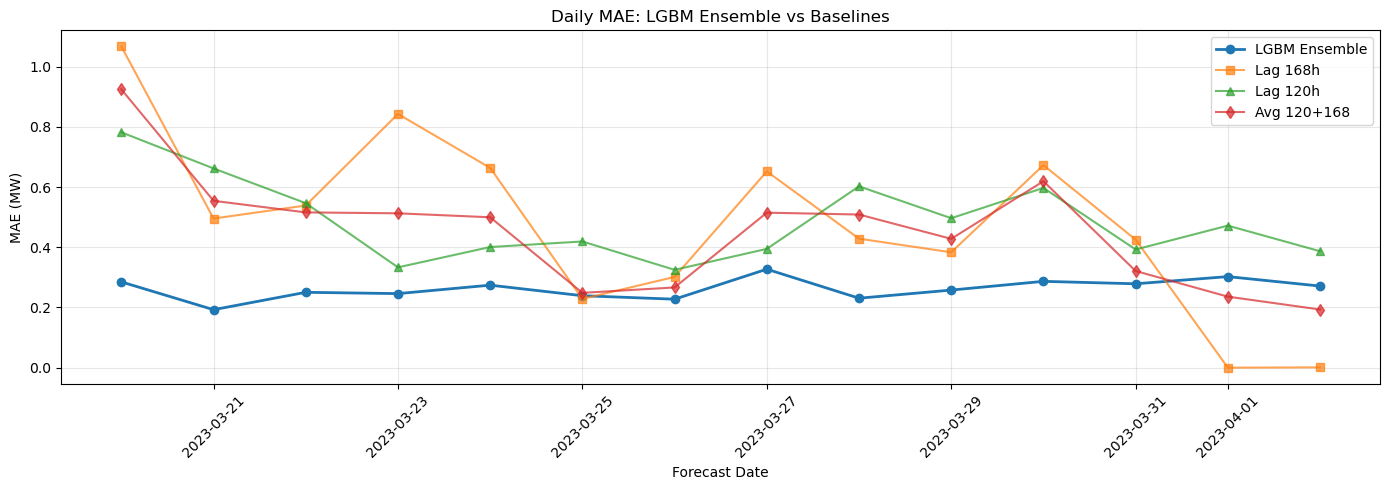

In [90]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_metrics_ens["forecast_date"], daily_metrics_ens["MAE"],
        marker="o", label="LGBM Ensemble", linewidth=2)
ax.plot(lag168_metrics["forecast_date"], lag168_metrics["MAE"],
        marker="s", label="Lag 168h", alpha=0.7)
ax.plot(lag120_metrics["forecast_date"], lag120_metrics["MAE"],
        marker="^", label="Lag 120h", alpha=0.7)
ax.plot(avg_metrics["forecast_date"], avg_metrics["MAE"],
        marker="d", label="Avg 120+168", alpha=0.7)

ax.set_title("Daily MAE: LGBM Ensemble vs Baselines")
ax.set_xlabel("Forecast Date")
ax.set_ylabel("MAE (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.2 Per-Location Analysis

Two views of location-level performance. The time series plot shows true vs predicted consumption per location alongside the best baseline, revealing where the model tracks well and where it diverges. The bar chart compares MAE across locations for the ensemble vs baseline, making it immediately visible which locations benefit most from the model.

Consumption scales differ substantially (Oslo ~10 MW, Tromsø ~1.5 MW), so visual fit on the time series plots should be interpreted relative to each location's range. The z-score standardization ensures equal training attention across locations, but final MW errors will naturally be larger for high-consumption locations.

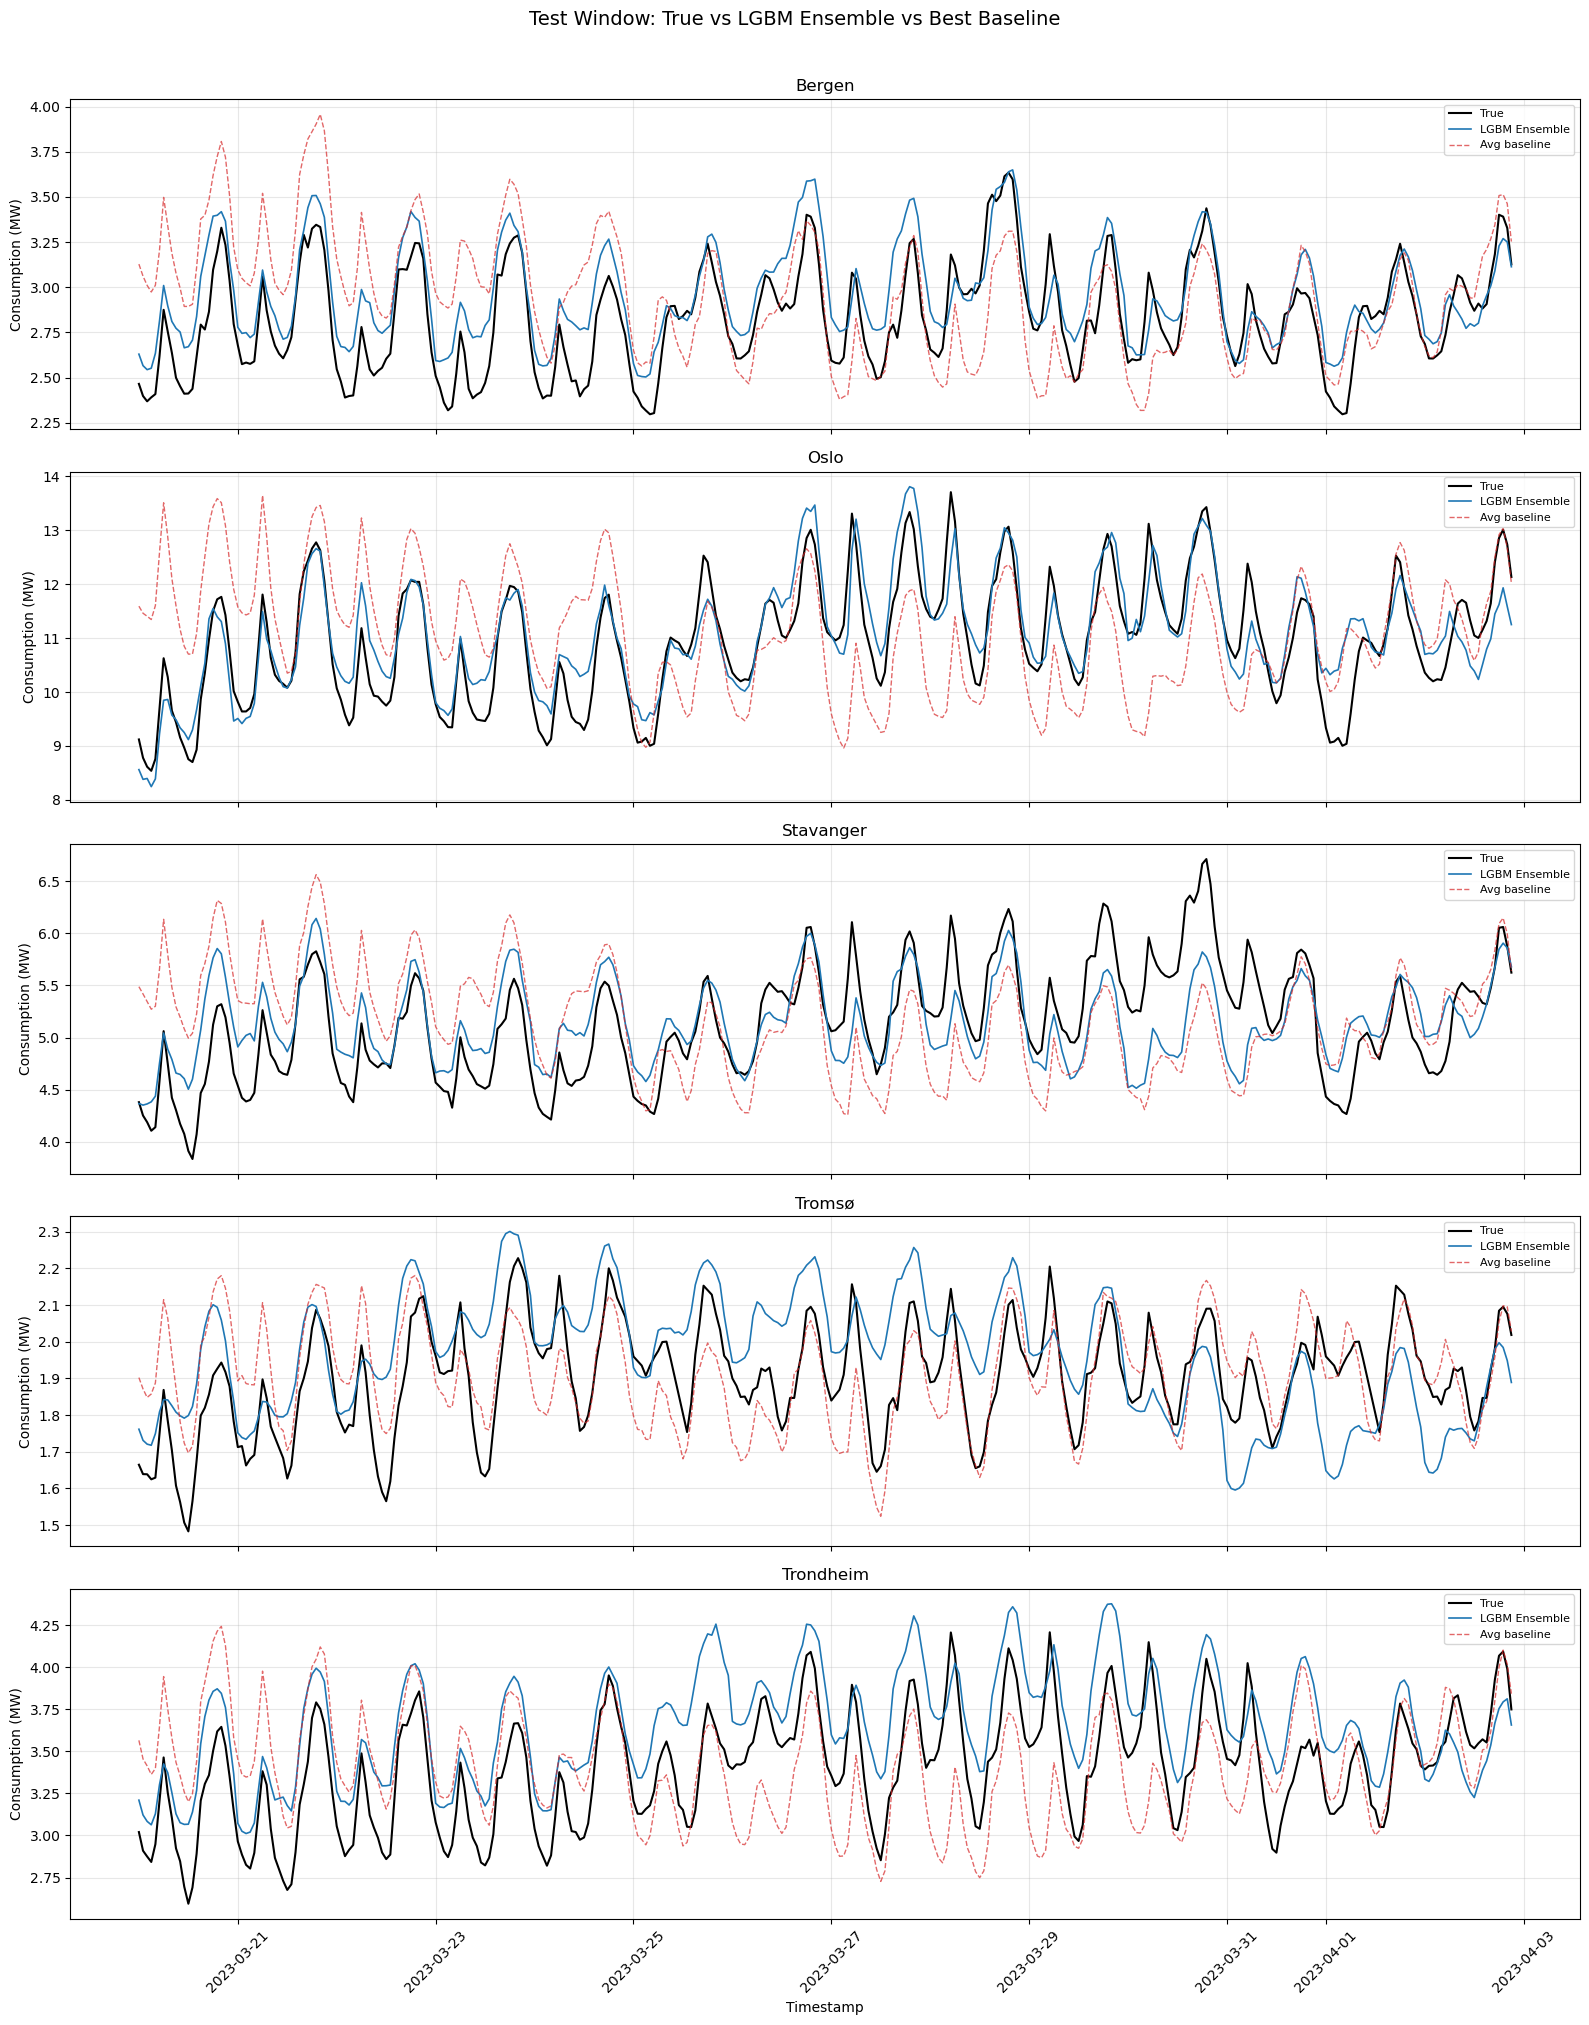

In [91]:
locations = sorted(predictions["location"].unique())
best_baseline = avg_preds.rename(columns={"y_pred": "y_pred_baseline"})

fig, axes = plt.subplots(len(locations), 1, figsize=(16, 4 * len(locations)), sharex=True)

for ax, loc in zip(axes, locations):
    loc_pred = predictions[predictions["location"] == loc].sort_values("timestamp")
    loc_base = best_baseline[best_baseline["location"] == loc].sort_values("timestamp")

    ax.plot(loc_pred["timestamp"], loc_pred["y_true_mw"],
            color="black", label="True", linewidth=1.5)
    ax.plot(loc_pred["timestamp"], loc_pred["y_pred_mw"],
            color="tab:blue", label="LGBM Ensemble", linewidth=1.2)
    ax.plot(loc_base["timestamp"], loc_base["y_pred_baseline"],
            color="tab:red", label="Avg baseline", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(loc.capitalize())
    ax.set_ylabel("Consumption (MW)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestamp")
plt.xticks(rotation=45)
plt.suptitle("Test Window: True vs LGBM Ensemble vs Best Baseline", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7.3 Error Analysis

Three breakdowns of model errors to identify systematic patterns:

- **Error distribution:** Histogram of signed and absolute errors for the ensemble vs baseline. A well-calibrated model should have errors centered near zero with no visible skew. Heavier tails than the baseline indicate the model occasionally makes large mistakes the baseline avoids.
- **MAE by hour:** Reveals which times of day are hardest to predict. Morning ramp-up (6–9 AM) and evening peak (17–19) typically show higher errors due to rapid consumption transitions. Hours where the model underperforms the baseline suggest the hourly consumption shape isn't fully captured.
- **Weekday vs weekend:** Consumption patterns differ on weekends (later morning ramp, lower midday consumption). If weekend MAE is disproportionately high, the calendar features may not be providing enough signal to distinguish the two regimes.

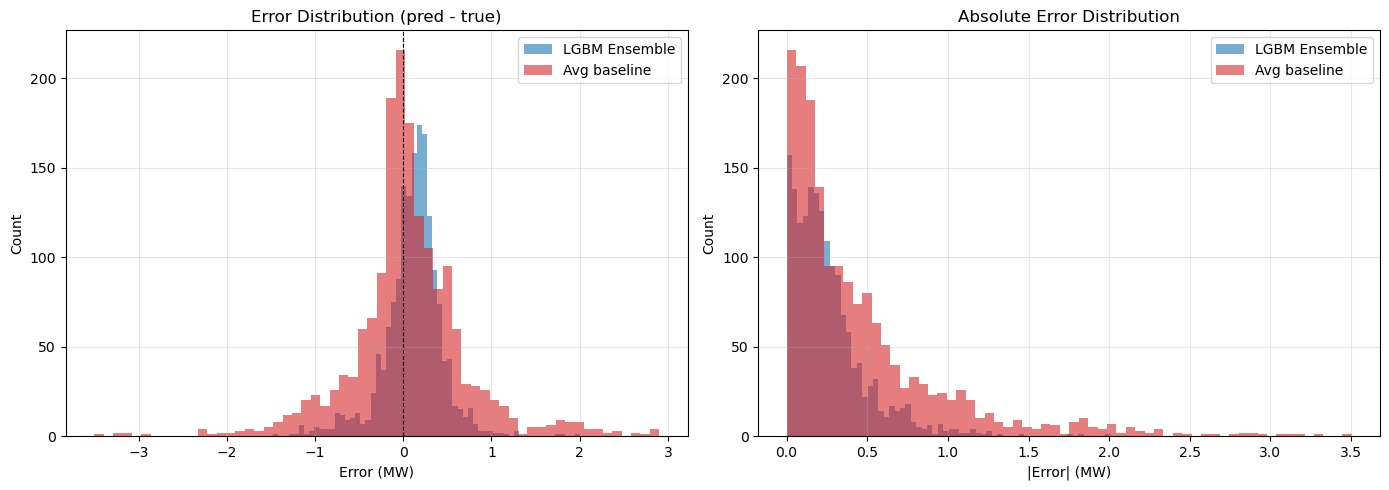

LGBM Ensemble — mean error: 0.1116 MW, std: 0.3315
Avg baseline  — mean error: 0.0535 MW, std: 0.6780


In [92]:
err_lgbm = predictions["y_pred_mw"] - predictions["y_true_mw"]
err_base = avg_preds["y_pred"] - avg_preds["y_true"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(err_lgbm, bins=60, alpha=0.6, label="LGBM Ensemble", color="tab:blue")
axes[0].hist(err_base, bins=60, alpha=0.6, label="Avg baseline", color="tab:red")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Error Distribution (pred - true)")
axes[0].set_xlabel("Error (MW)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.abs(err_lgbm), bins=60, alpha=0.6, label="LGBM Ensemble", color="tab:blue")
axes[1].hist(np.abs(err_base), bins=60, alpha=0.6, label="Avg baseline", color="tab:red")
axes[1].set_title("Absolute Error Distribution")
axes[1].set_xlabel("|Error| (MW)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"LGBM Ensemble — mean error: {err_lgbm.mean():.4f} MW, std: {err_lgbm.std():.4f}")
print(f"Avg baseline  — mean error: {err_base.mean():.4f} MW, std: {err_base.std():.4f}")

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/2781070925.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_lgbm = predictions.groupby("hour").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/2781070925.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_base = avg_preds.groupby("hour").apply(lambda g: mae(g["y_true

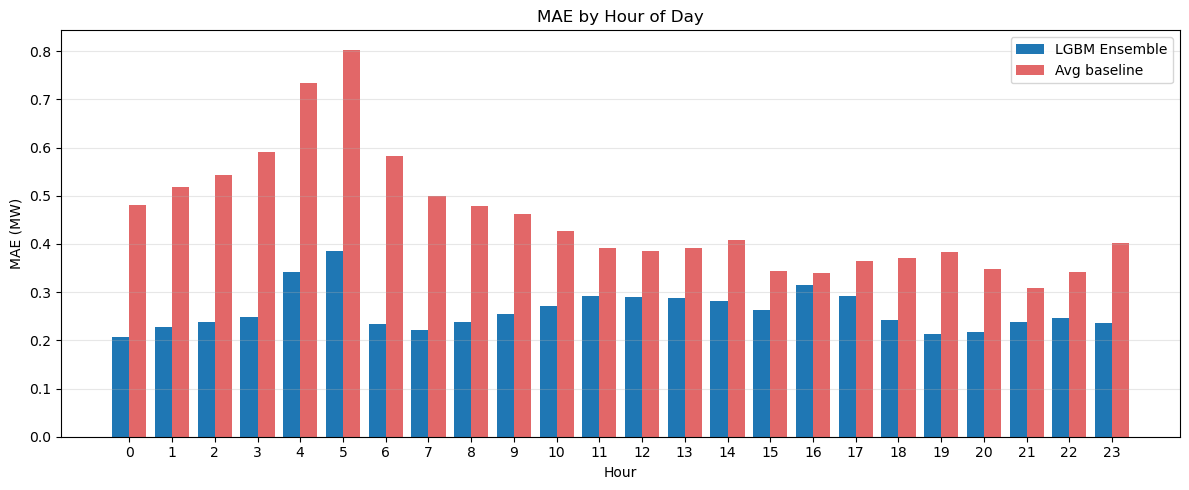

In [93]:
predictions["hour"] = pd.to_datetime(predictions["timestamp"]).dt.hour
avg_preds["hour"] = pd.to_datetime(avg_preds["timestamp"]).dt.hour

hourly_lgbm = predictions.groupby("hour").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
hourly_base = avg_preds.groupby("hour").apply(lambda g: mae(g["y_true"], g["y_pred"]))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_lgbm.index - 0.2, hourly_lgbm.values, width=0.4,
       label="LGBM Ensemble", color="tab:blue")
ax.bar(hourly_base.index + 0.2, hourly_base.values, width=0.4,
       label="Avg baseline", color="tab:red", alpha=0.7)
ax.set_title("MAE by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE (MW)")
ax.set_xticks(range(24))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/1668587877.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_lgbm = predictions.groupby("location").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/1668587877.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loc_lgbm = predictions.groupby("location").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_81419/16685

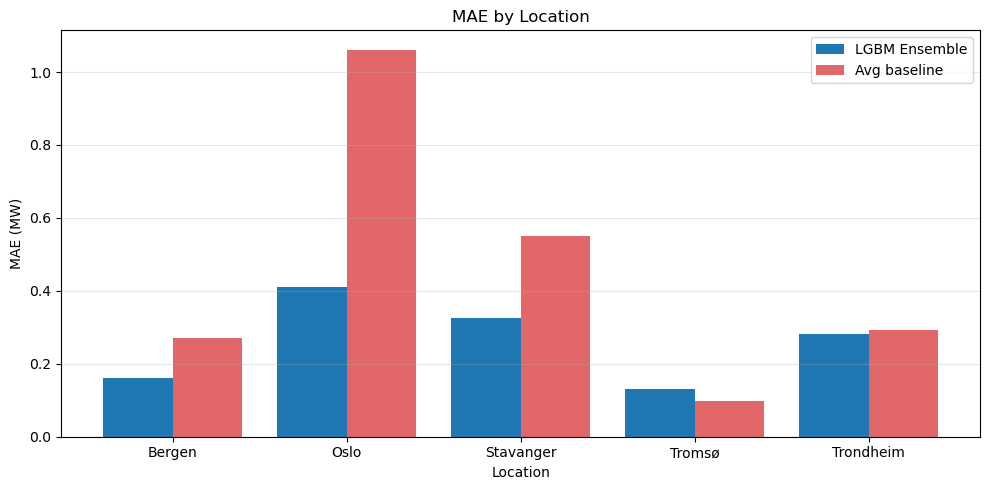

In [94]:
loc_lgbm = predictions.groupby("location").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
loc_base = avg_preds.groupby("location").apply(lambda g: mae(g["y_true"], g["y_pred"]))

loc_names = loc_lgbm.index
x = np.arange(len(loc_names))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, loc_lgbm.values, width=0.4,
       label="LGBM Ensemble", color="tab:blue")
ax.bar(x + 0.2, loc_base.values, width=0.4,
       label="Avg baseline", color="tab:red", alpha=0.7)
ax.set_title("MAE by Location")
ax.set_xlabel("Location")
ax.set_ylabel("MAE (MW)")
ax.set_xticks(x)
ax.set_xticklabels([n.capitalize() for n in loc_names])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

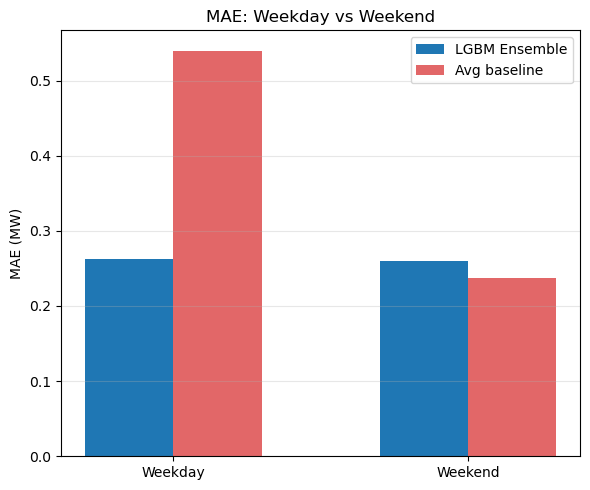

In [95]:
predictions["is_wknd"] = pd.to_datetime(predictions["timestamp"]).dt.dayofweek >= 5
avg_preds["is_wknd"] = pd.to_datetime(avg_preds["timestamp"]).dt.dayofweek >= 5

lgbm_wk = [mae(g["y_true_mw"], g["y_pred_mw"]) for _, g in predictions.groupby("is_wknd")]
base_wk = [mae(g["y_true"], g["y_pred"]) for _, g in avg_preds.groupby("is_wknd")]

x = np.arange(2)
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - 0.15, lgbm_wk, width=0.3, label="LGBM Ensemble", color="tab:blue")
ax.bar(x + 0.15, base_wk, width=0.3, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set_title("MAE: Weekday vs Weekend")
ax.set_xticks(x)
ax.set_xticklabels(["Weekday", "Weekend"])
ax.set_ylabel("MAE (MW)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8. Model Diagnostics

### 8.1 Feature Importance

Feature importance (total gain) for each ensemble member individually. Since the three models use different feature subsets and objectives, their importance rankings should differ substantially — this confirms genuine model diversity.

**What to look for:**
- **Model A** should be driven by a mix of consumption lags and temperature features, reflecting its access to the full feature set
- **Model C** should show temperature-related features dominating since it has no consumption lags available
- **Model D** should spread importance more evenly across fewer splits — with only 4 leaves, no single feature can dominate

Features that rank near zero across all models are candidates for removal in future iterations.

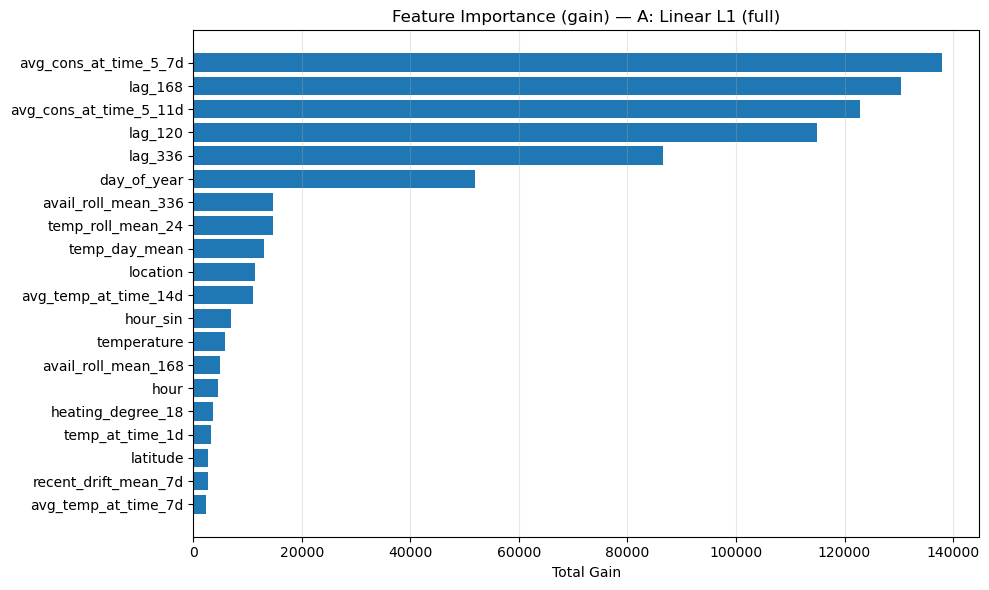

A: Linear L1 (full) — 29 features, top 3: avg_cons_at_time_5_7d, lag_168, avg_cons_at_time_5_11d



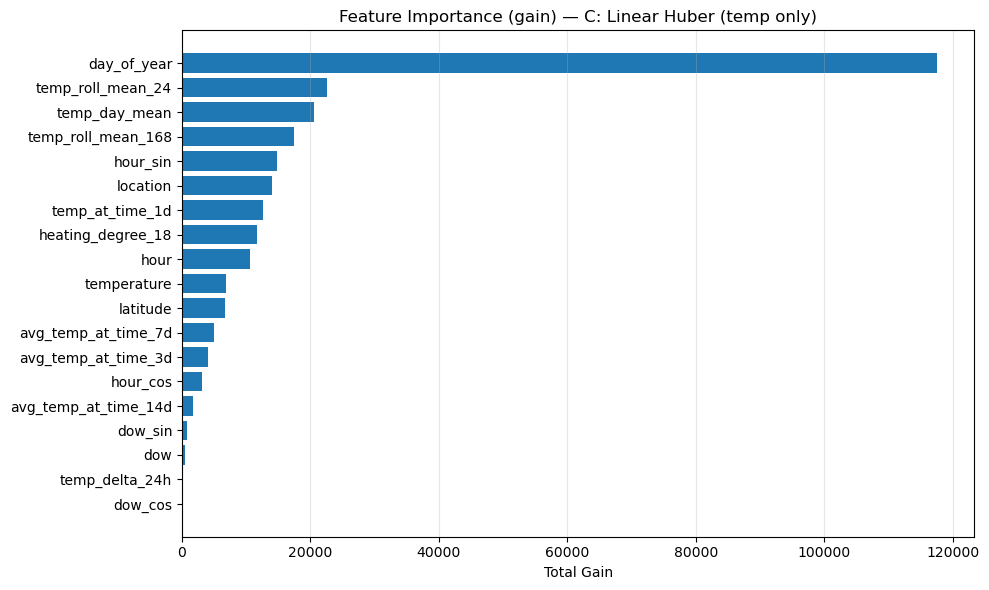

C: Linear Huber (temp only) — 19 features, top 3: day_of_year, temp_roll_mean_24, temp_day_mean



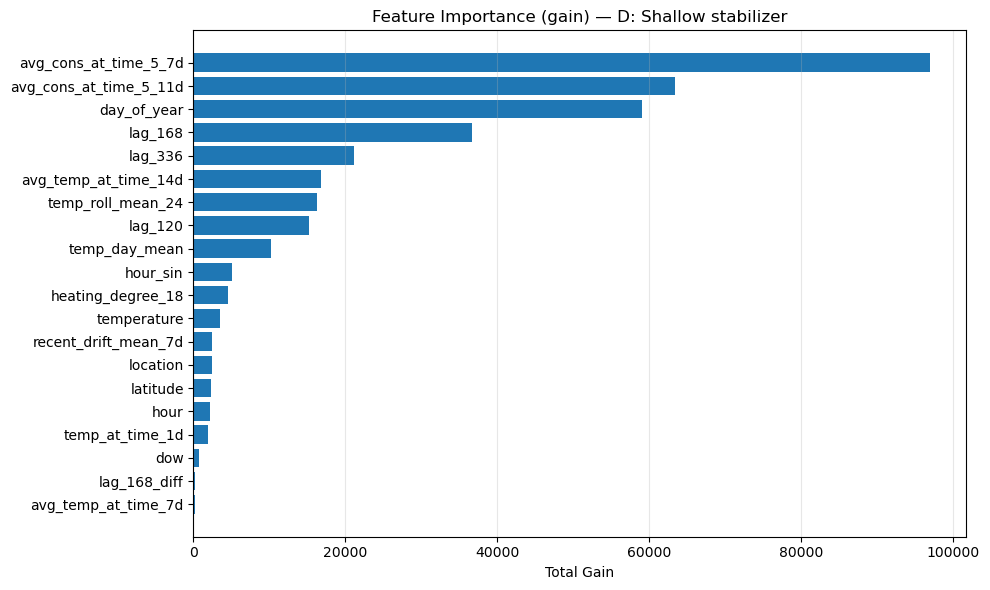

D: Shallow stabilizer — 29 features, top 3: avg_cons_at_time_5_7d, avg_cons_at_time_5_11d, day_of_year



In [96]:
# ═══════════════════════════════════════════
# Feature importance for all ensemble models
# ═══════════════════════════════════════════
last = test_splits[-1]

for config in ensemble_configs:
    model, feat_cols = train_diverse_model(config, last.X_train, last.y_train)

    imp = pd.DataFrame({
        "feature": feat_cols,
        "gain": model.booster_.feature_importance(importance_type="gain"),
    }).sort_values("gain", ascending=False)

    TOP_N = min(20, len(imp))
    top = imp.head(TOP_N).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["gain"], color="tab:blue")
    ax.set_title(f"Feature Importance (gain) — {config['name']}")
    ax.set_xlabel("Total Gain")
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    print(f"{config['name']} — {len(feat_cols)} features, "
          f"top 3: {', '.join(imp['feature'].head(3).tolist())}\n")

### 8.2 Ensemble Weights

Stacked bar chart showing the per-location blend weights learned from the tune window. This is the most direct visualization of the ensemble strategy — it makes explicit which model each location relies on most.

Locations where one model dominates (weight > 0.6) suggest that location's consumption pattern is well-captured by a specific modeling approach. Locations with more balanced weights benefit from genuine model averaging. If weights diverge dramatically from equal, the per-location optimization is earning its keep. If all locations show similar weights, the per-location strategy adds complexity without benefit and could be simplified to global weights.

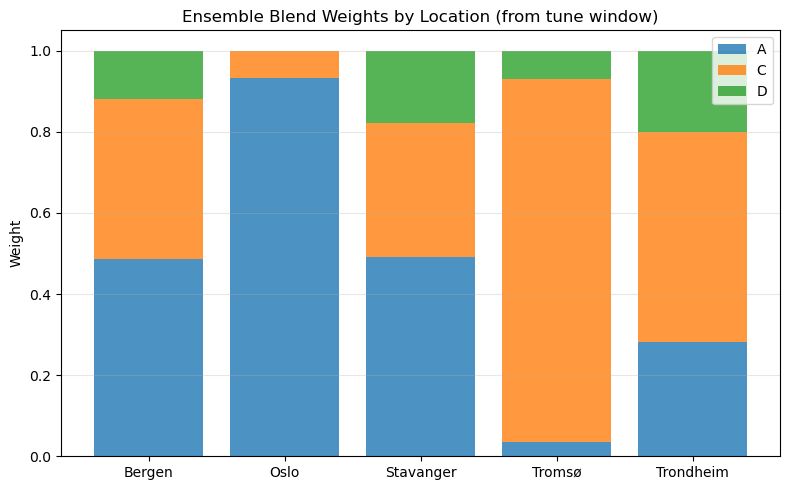

In [97]:
locs = sorted(location_weights.keys())
model_names = list(location_weights[locs[0]].keys())
short_names = [n.split(":")[0] for n in model_names]

weight_matrix = np.array([[location_weights[loc][m] for m in model_names] for loc in locs])

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(locs))
colors = ["tab:blue", "tab:orange", "tab:green"]

for i, (name, color) in enumerate(zip(short_names, colors)):
    ax.bar([l.capitalize() for l in locs], weight_matrix[:, i],
           bottom=bottom, label=name, color=color, alpha=0.8)
    bottom += weight_matrix[:, i]

ax.set_title("Ensemble Blend Weights by Location (from tune window)")
ax.set_ylabel("Weight")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 8.3 Partial Dependence

Partial dependence plots show the model's learned response to each key feature in isolation, averaging out the effect of all other features. These are the most interpretable view of what the model has actually learned.

**Expected relationships:**
- **Temperature:** Negative slope — higher temperature means less heating demand
- **Heating degree:** Positive slope — mirrors temperature but zeroed out above 18°C
- **Hour:** Daily consumption shape — trough at ~4 AM, peaks at morning and evening
- **Lag 168:** Near-linear positive — last week's same-hour consumption is the strongest anchor
- **Day of year:** Seasonal curve — higher in winter, lower in summer

Unexpected shapes (e.g. temperature showing a positive slope in some range, or hour showing no daily pattern) would indicate a problem with feature construction or data leakage. Non-monotonic responses in temperature may reflect the spring transition in the training data where the relationship between temperature and consumption is less stable.

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 7 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 9 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


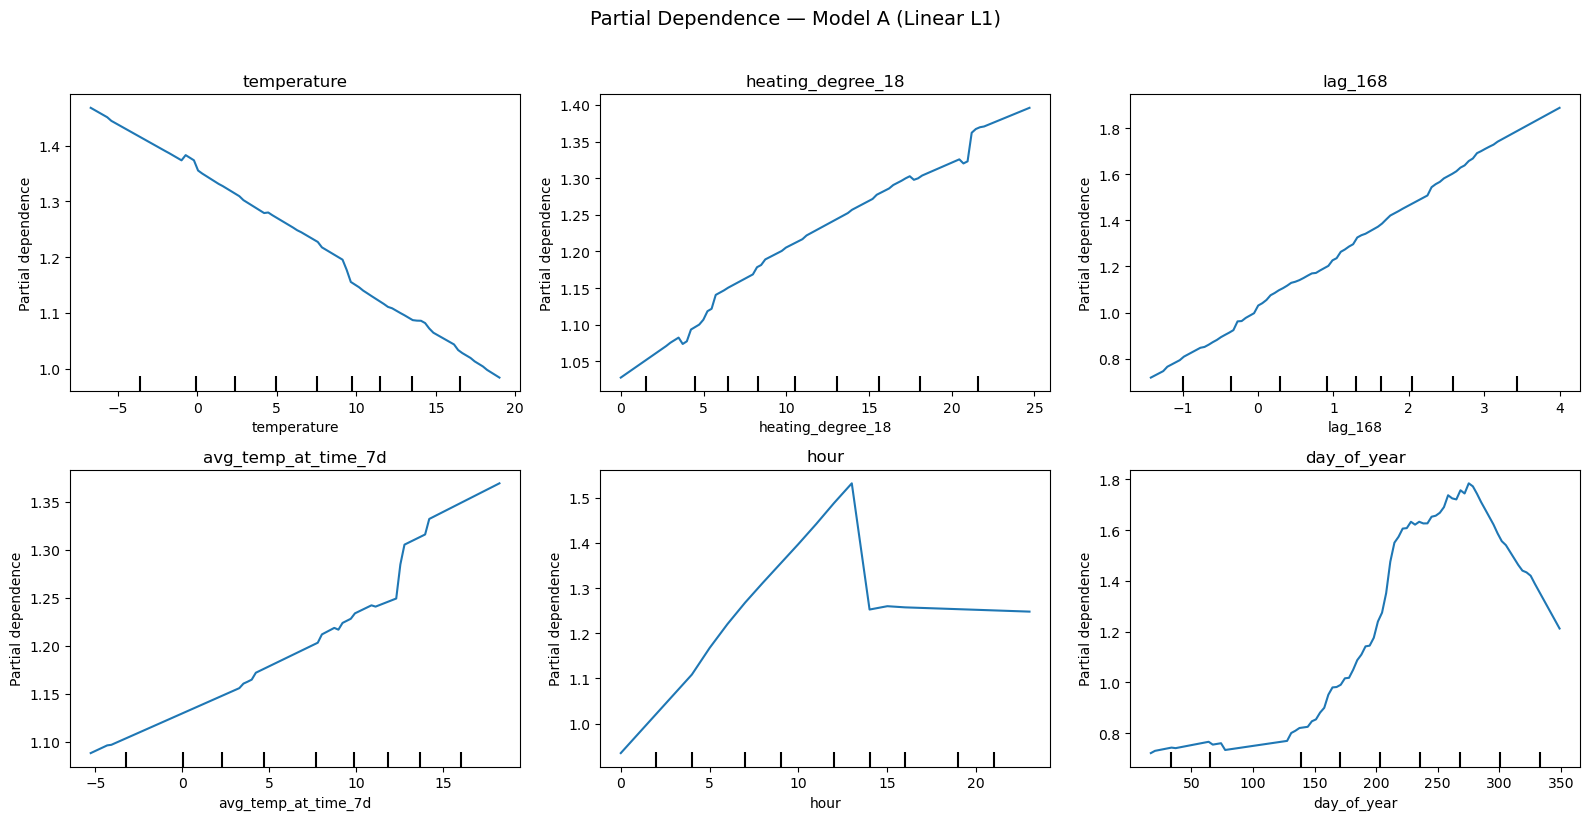

In [100]:
from sklearn.inspection import PartialDependenceDisplay

last = test_splits[-1]
model = make_model({**best_params_a, "n_estimators": best_n_estimators_a})
model.fit(last.X_train, last.y_train, categorical_feature=cat_features)

key_features = ["temperature", "heating_degree_18", "lag_168",
                "avg_temp_at_time_7d", "hour", "day_of_year"]
# Filter to features that exist in training data
key_features = [f for f in key_features if f in last.X_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, key_features):
    PartialDependenceDisplay.from_estimator(
        model, last.X_train, [feat], ax=ax,
        line_kw={"color": "tab:blue"},
    )
    ax.set_title(feat)
    ax.grid(True, alpha=0.3)

plt.suptitle("Partial Dependence — Model A (Linear L1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8.4 Residual Autocorrelation

Autocorrelation of prediction errors at lags 1–48 hours, plotted per location. Red dashed lines mark the 95% significance threshold — bars within the bands indicate random, uncorrelated errors, which is the ideal outcome.

**Patterns to watch for:**
- **Significant autocorrelation at lag 24:** The model is consistently missing a daily pattern — errors at 3 PM today predict errors at 3 PM tomorrow. This would suggest the hourly consumption shape isn't fully captured.
- **Significant autocorrelation at lag 1:** Consecutive hours have correlated errors — the model is making similar mistakes in blocks, likely over- or under-predicting for stretches of several hours at a time.
- **Slowly decaying autocorrelation:** The model is missing a trend — it's systematically biased high or low for extended periods, suggesting the drift or rolling mean features aren't doing their job.

Locations with strong residual structure are the best candidates for further feature engineering or dedicated specialist models.

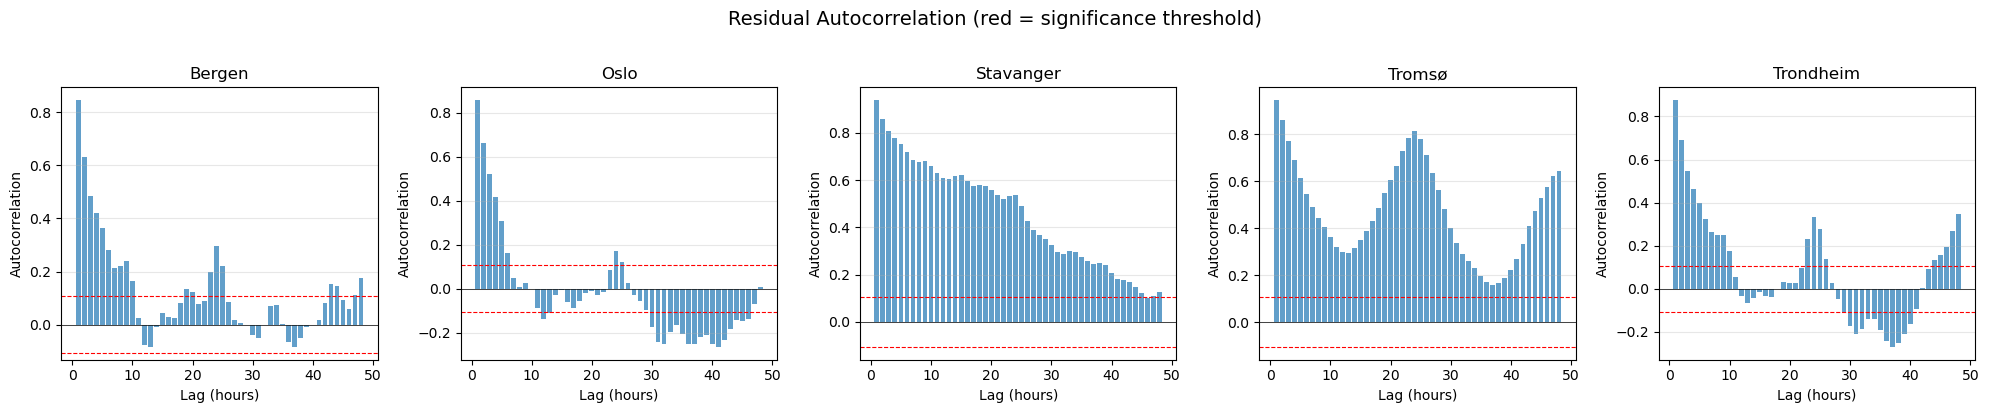

In [101]:
fig, axes = plt.subplots(1, len(predictions["location"].unique()),
                         figsize=(4 * len(predictions["location"].unique()), 4))

for ax, loc in zip(axes, sorted(predictions["location"].unique())):
    loc_data = predictions[predictions["location"] == loc].sort_values("timestamp")
    residuals = loc_data["y_pred_mw"].values - loc_data["y_true_mw"].values

    # Autocorrelation at lags 1-48 hours
    max_lag = min(48, len(residuals) - 1)
    autocorr = [np.corrcoef(residuals[:-lag], residuals[lag:])[0, 1]
                for lag in range(1, max_lag + 1)]

    ax.bar(range(1, max_lag + 1), autocorr, color="tab:blue", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(1.96 / np.sqrt(len(residuals)), color="red", linestyle="--", linewidth=0.8)
    ax.axhline(-1.96 / np.sqrt(len(residuals)), color="red", linestyle="--", linewidth=0.8)
    ax.set_title(loc.capitalize())
    ax.set_xlabel("Lag (hours)")
    ax.set_ylabel("Autocorrelation")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Residual Autocorrelation (red = significance threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8.5 Tree Structure Analysis

Two views into how the primary model (Model A) constructs its decision trees internally.

**Leaf value distribution:** Shows the magnitude of corrections each tree makes. A tight distribution centered near zero indicates a conservative model that makes many small adjustments — typical of well-regularized ensembles with linear trees. A wide distribution with heavy tails suggests individual trees are making aggressive predictions, which can indicate overfitting.

**Split feature counts:** A complementary view to gain-based feature importance. Split count shows which features are used most often for *routing* data through the trees, regardless of how much each split improves the prediction. Features that rank high on splits but low on gain are "routing" features (e.g. `hour` and `location` which direct data to the right leaf). Features high on gain but lower on splits are "value" features (e.g. `temperature` which determines the prediction magnitude within a leaf). Both roles are essential — the model needs accurate routing to reach the right leaf, and informative value features to make good predictions once there.

Total leaves across all trees: 1190
Mean leaf value:  0.0077
Std leaf value:   0.1004
Min leaf value:   -0.0648
Max leaf value:   1.3486


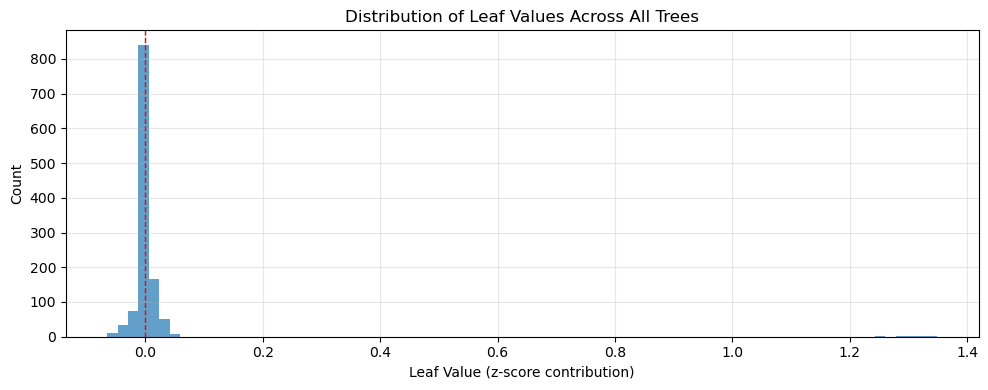

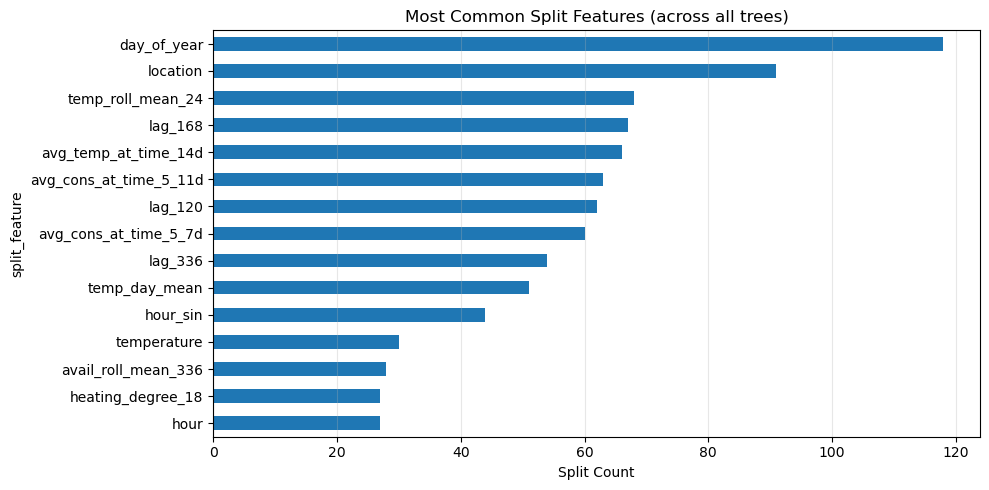

In [103]:
last = test_splits[-1]
model = make_model({**best_params_a, "n_estimators": best_n_estimators_a})
model.fit(last.X_train, last.y_train, categorical_feature=cat_features)

# Extract the model's tree structure
trees_df = model.booster_.trees_to_dataframe()

# Linear tree models store leaf values differently — check leaf statistics
leaf_rows = trees_df[trees_df["left_child"].isna()]
print(f"Total leaves across all trees: {len(leaf_rows)}")
print(f"Mean leaf value:  {leaf_rows['value'].mean():.4f}")
print(f"Std leaf value:   {leaf_rows['value'].std():.4f}")
print(f"Min leaf value:   {leaf_rows['value'].min():.4f}")
print(f"Max leaf value:   {leaf_rows['value'].max():.4f}")

# Distribution of leaf values
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(leaf_rows["value"], bins=80, color="tab:blue", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Distribution of Leaf Values Across All Trees")
ax.set_xlabel("Leaf Value (z-score contribution)")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Most common split features
split_rows = trees_df[trees_df["left_child"].notna()]
split_counts = split_rows["split_feature"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
split_counts.iloc[::-1].plot.barh(ax=ax, color="tab:blue")
ax.set_title("Most Common Split Features (across all trees)")
ax.set_xlabel("Split Count")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Note

The LGBM model structure IS ALREADY an enemble model -> it is an ensemble of mutiple boosting trees -> boosting forrest. Calling the combination of 3 different LGBM setups an ensemble is a bit 'misleading'. The distinction of what is an ensemble and what is not, is not separated in the layers of a single LGBM model and adding more LGBM models.

### Further potential improvements

- more specific isolated studies of features and hyperparameters
- Auto-tuning on the complimentary models
- Cross-location feedback in the prediciton aggregates/or as features
- rolling window backtest- test multiple windows in the data, BUT we perform auto tuning for the specific period we want to predict, and this will auto-tune for other chosen windows
- cross validation
- The model has a clear over-prediction bias because it is validated on a colder period
- better blending- some locations clearly perform worse, while ex. Oslo excels
- location specialist models
- Currently the 5 day delay is treated as a blind spot- we could supplement temperature data, which could provide useful information

- supplementary quartile/percentile models, which could support stability and/or offer a better image of risk involved in periods